C:\Users\admin\AppData\Local\Temp\ipykernel_7664\3092255152.py:28: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  sc = ax.scatter(longitudes, latitudes, c=colors, cmap=cmap_radar, vmin=0, vmax=1)


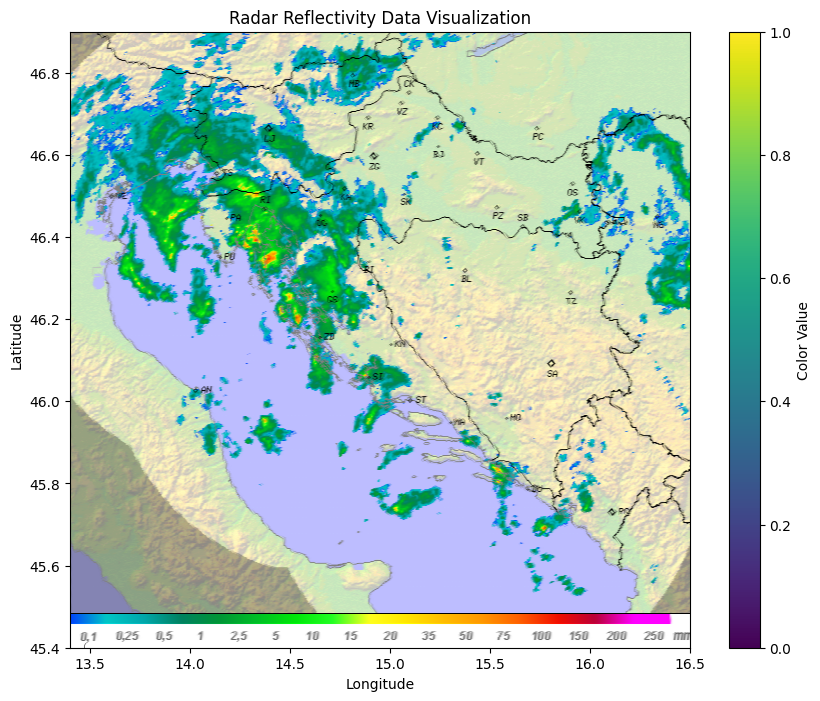

In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Read data from CSV file
csv_filename = './radar_data.csv'  # Replace with the actual filename
data = []

with open(csv_filename, 'r') as csvfile:
    csv_reader = csv.DictReader(csvfile)
    for row in csv_reader:
        latitude = float(row['Latitude'])
        longitude = float(row['Longitude'])
        color_values = np.fromstring(row['Value'][1:-1], dtype=int, sep=' ') / 255.0  # Normalize to [0, 1]
        data.append((latitude, longitude, color_values))

# Extract latitude, longitude, and color values
latitudes = [entry[0] for entry in data]
longitudes = [entry[1] for entry in data]
colors = [entry[2] for entry in data]

# Create a colormap based on radar reflectivity
cmap_radar = ListedColormap(colors, name='RadarReflectivity')

# Create a scatter plot with the specified colormap
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(longitudes, latitudes, c=colors, cmap=cmap_radar, vmin=0, vmax=1)

# Set labels and title
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Radar Reflectivity Data Visualization')

# Define bounding box for Slovenia
min_lat_slovenia = 45.4
max_lat_slovenia = 46.9
min_lon_slovenia = 13.4
max_lon_slovenia = 16.5

# Set limits to focus on Slovenia
ax.set_xlim(min_lon_slovenia, max_lon_slovenia)
ax.set_ylim(min_lat_slovenia, max_lat_slovenia)

# Create a colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Color Value')

# Show the plot
plt.show()
